## Run Inference

In [11]:
# import torch
# import torch.nn as nn
# from torchvision import models

# MODEL_PATH = "../speciesnet/last_model_state_resnet18_20260205_082643.pkl"
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ckpt = torch.load(MODEL_PATH, map_location=DEVICE)

# print("Checkpoint keys:", ckpt.keys())

# state_dict = ckpt["model_state"]  # <-- MUST be this
# class_names = ckpt.get("class_names", None)
# num_classes = len(class_names) if class_names is not None else 2

# # --- handle DataParallel 'module.' prefix ---
# def strip_module_prefix(sd):
#     if any(k.startswith("module.") for k in sd.keys()):
#         return {k.replace("module.", "", 1): v for k, v in sd.items()}
#     return sd

# state_dict = strip_module_prefix(state_dict)

# # --- build model with matching head size ---
# model = models.resnet18(weights=None)
# model.fc = nn.Linear(model.fc.in_features, num_classes)

# # --- sanity print: compare a couple keys ---
# sd_keys = list(state_dict.keys())
# print("Example state_dict keys:", sd_keys[:5])
# print("Model expects fc.weight shape:", model.fc.weight.shape)
# print("State dict fc.weight shape:", state_dict.get("fc.weight", None).shape if "fc.weight" in state_dict else "MISSING")

# # --- attempt load with strict=False so we can SEE mismatches ---
# missing, unexpected = model.load_state_dict(state_dict, strict=False)

# print("\nMissing keys (first 20):", missing[:20])
# print("Unexpected keys (first 20):", unexpected[:20])

# # If strict=False loads cleanly (only fc mismatch etc), you can decide next.

In [13]:
import os, re
import torch
import torch.nn as nn
import pandas as pd
from tqdm import tqdm
import torchvision.transforms as T
from torchvision.transforms import InterpolationMode
from torchvision.io import read_image
from torchvision import models

MODEL_PATH = "../speciesnet/last_model_state_resnet18_20260205_082643.pkl"
IMG_DIR = "/mnt/sharedstorage/sabdelazim/images/all_species_images"
OUT_CSV = "bird_inference_results.csv"
SIZE = 224
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---------- filename parser ----------
def parse_filename(filename):
    base = os.path.splitext(filename)[0]
    parts = base.split("_")
    site_pat = re.compile(r"^[a-zA-Z]\d{2}$")
    for i, part in enumerate(parts):
        if site_pat.match(part):
            site = part.lower()
            species = "_".join(parts[i + 1:]).lower()
            return species, site
    return None, None

# ---------- transform (your training) ----------
def transform_torch(path: str, size: int = 224) -> torch.Tensor:
    img = read_image(path)  # [C,H,W] uint8
    img = T.functional.resize(
        img, [size, size],
        interpolation=InterpolationMode.BILINEAR,
        antialias=False
    )
    img = img.float().div_(255.0)
    img = T.functional.normalize(img, [0.485, 0.456, 0.406],
                                      [0.229, 0.224, 0.225])
    return img

# ---------- wrapper model to match checkpoint ----------
class WrappedResnet18(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        backbone = models.resnet18(weights=None)
        feat_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.feature_extractor = backbone
        self.classifier = nn.Linear(feat_dim, num_classes)

    def forward(self, x):
        feats = self.feature_extractor(x)
        return self.classifier(feats)

# ---------- load ckpt ----------
ckpt = torch.load(MODEL_PATH, map_location=DEVICE)
class_names = ckpt["class_names"]
num_classes = len(class_names)

model = WrappedResnet18(num_classes=num_classes)
model.load_state_dict(ckpt["model_state"], strict=True)
model.to(DEVICE).eval()

print("Loaded wrapper model. Num classes:", num_classes)
print("Classes:", class_names)

# ---------- collect antelope files ----------
valid_ext = (".jpg", ".jpeg", ".png", ".webp")
all_files = [f for f in os.listdir(IMG_DIR) if f.lower().endswith(valid_ext)]
antelope_files = [f for f in all_files if (parse_filename(f)[0] == "bird_other")]

print("Found bird images:", len(antelope_files))

# ---------- inference ----------
rows = []
with torch.no_grad():
    for fname in tqdm(antelope_files):
        path = os.path.join(IMG_DIR, fname)
        x = transform_torch(path, size=SIZE).unsqueeze(0).to(DEVICE)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[0]
        pred_idx = int(probs.argmax().item())
        pred_conf = float(probs[pred_idx].item())

        true_species, site = parse_filename(fname)
        rows.append({
            "filename": fname,
            "site": site,
            "true_class_from_name": true_species,
            "pred_class_idx": pred_idx,
            "pred_class_label": class_names[pred_idx],
            "pred_conf": pred_conf,
        })

df_out = pd.DataFrame(rows)
df_out.to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV)

Loaded wrapper model. Num classes: 28
Classes: ['waterbuck', 'baboon', 'warthog', 'impala', 'bushbuck', 'oribi', 'elephant', 'genet', 'nyala', 'wildebeest', 'reedbuck', 'civet', 'mongoose_marsh', 'mongoose_white_tailed', 'mongoose_slender', 'mongoose_banded', 'mongoose_bushy_tailed', 'mongoose_large_grey', 'mongoose_dwarf', 'bushpig', 'duiker_common', 'duiker_red', 'duiker', 'buffalo', 'hippopotamus', 'hartebeest', 'eland', 'pangolin']
Found bird images: 3444


100%|███████████████████████████████████████| 3444/3444 [00:52<00:00, 65.75it/s]

Saved: bird_inference_results.csv


## Graph (Antelope)

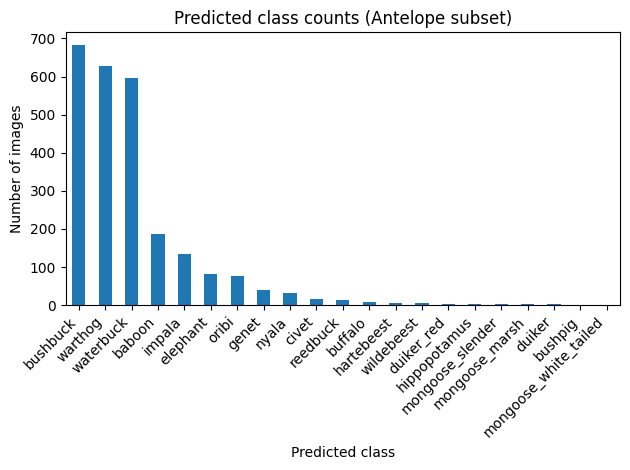

In [8]:
import pandas as pd

df = pd.read_csv("antelope_inference_results.csv")
df["pred_conf"] = df["pred_conf"].astype(float)


import matplotlib.pyplot as plt

counts = df["pred_class_label"].value_counts()

plt.figure()
counts.plot(kind="bar")
plt.ylabel("Number of images")
plt.xlabel("Predicted class")
plt.title("Predicted class counts (Antelope subset)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/tmp/ipykernel_401984/983157426.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


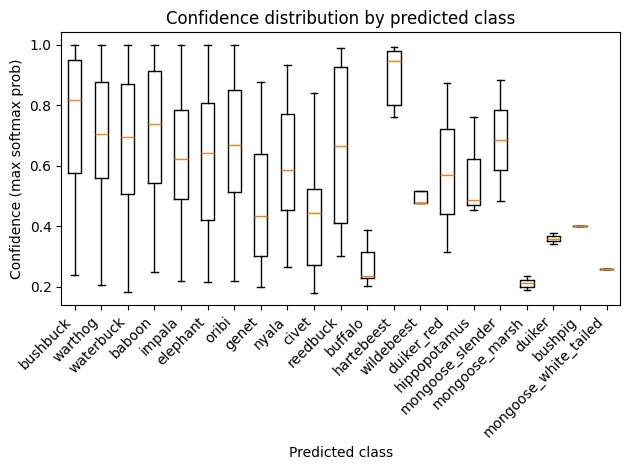

In [9]:
import numpy as np
import matplotlib.pyplot as plt

labels = counts.index.tolist()
data = [df.loc[df["pred_class_label"] == lab, "pred_conf"].values for lab in labels]

plt.figure()
plt.boxplot(data, labels=labels, showfliers=False)
plt.ylabel("Confidence (max softmax prob)")
plt.xlabel("Predicted class")
plt.title("Confidence distribution by predicted class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Graph (bird)

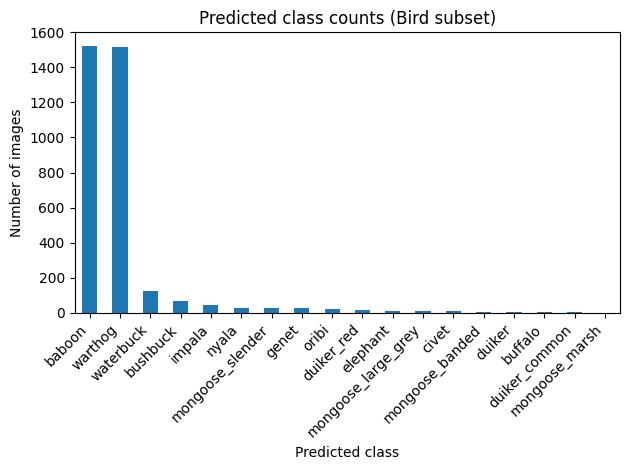

In [15]:
import pandas as pd

df = pd.read_csv("bird_inference_results.csv")
df["pred_conf"] = df["pred_conf"].astype(float)


import matplotlib.pyplot as plt

counts = df["pred_class_label"].value_counts()

plt.figure()
counts.plot(kind="bar")
plt.ylabel("Number of images")
plt.xlabel("Predicted class")
plt.title("Predicted class counts (Bird subset)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/tmp/ipykernel_401984/983157426.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


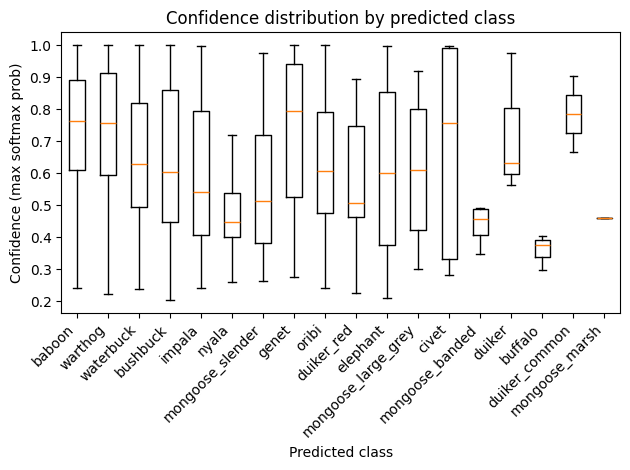

In [16]:
import numpy as np
import matplotlib.pyplot as plt

labels = counts.index.tolist()
data = [df.loc[df["pred_class_label"] == lab, "pred_conf"].values for lab in labels]

plt.figure()
plt.boxplot(data, labels=labels, showfliers=False)
plt.ylabel("Confidence (max softmax prob)")
plt.xlabel("Predicted class")
plt.title("Confidence distribution by predicted class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()